In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:

if __name__ == '__main__':
    # Hyperparameters
    # data_str = "ghq_b_sum"
    data_str = "ghq_sum"
    # data_str = "simulation"
    batch_size = 2          # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 8             # number of heads
    ncum = 8                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 100
    target_sample_size = 7
    nrepp = 10

    
    # load real data
    data, maxlen = load_real_data(data_str)
    

    n = len(data)
    p = data[0].shape[1]
    print("Sample size: ", len(data), "\n")
    
    train_dataset = data
    
    predindex = 9

    # Set the random seed for reproducibility
    seed = 999
    torch.manual_seed(seed)

    mask_pairwise = create_custom_mask_pair(maxlen, device)
    mask_pred = create_custom_mask_pred(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    
    model = MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise,mask_pred, pairwise_distance_matrix, distance_to_end_matrix,  device)

    model.apply(init_weights_recursive)
    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")




Sample size:  878 

Number of Parameters 420
EPOCH 1:
avg_loss: 16.96521
EPOCH 11:
avg_loss: 12.65288
EPOCH 21:
avg_loss: 12.26897
EPOCH 31:
avg_loss: 12.15646
EPOCH 41:
avg_loss: 12.12287
EPOCH 51:
avg_loss: 12.09417
EPOCH 61:
avg_loss: 12.05856
EPOCH 71:
avg_loss: 12.05243
EPOCH 81:
avg_loss: 12.04492
EPOCH 91:
avg_loss: 12.04746
Execution time: 34.353465 seconds


In [3]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


In [4]:
print_p_values(avepval, stdpval)

Variable 1: 0.4064 ± 0.16
Variable 2: 0.3283 ± 0.09
Variable 3: 0.1333 ± 0.12
Variable 4: 0.0465 ± 0.04
Variable 5: 0.5326 ± 0.16
Variable 6: 0.2111 ± 0.14
Variable 7: 0.6196 ± 0.08
Variable 8: 0.0397 ± 0.03
Variable 9: 0.0495 ± 0.05
Variable 10: 0.5837 ± 0.42


In [5]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall, nrepp)    

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


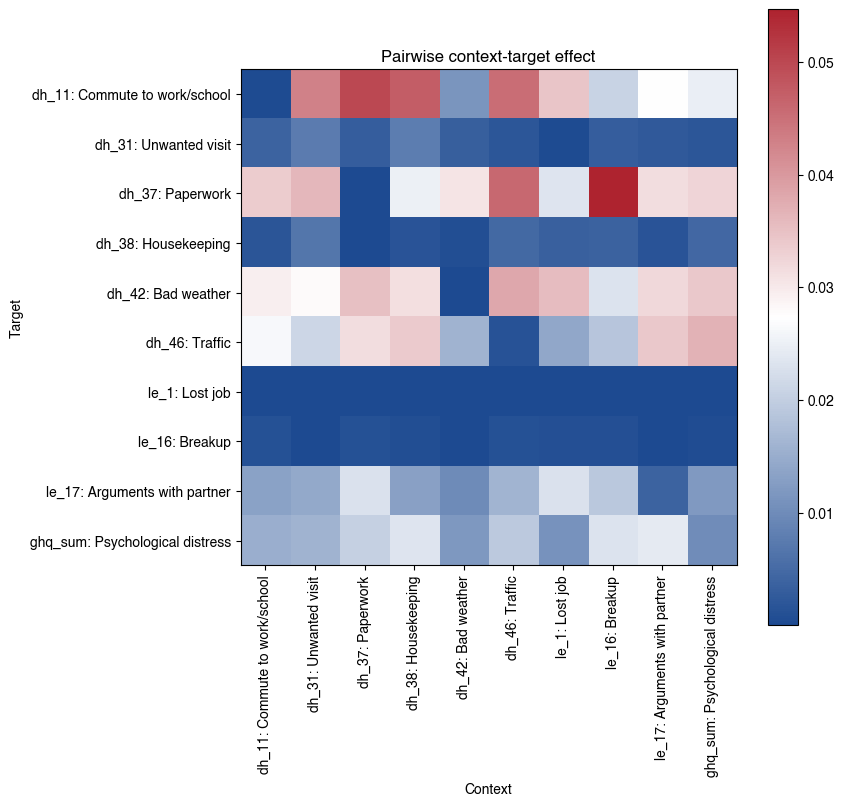

<module 'matplotlib.pyplot' from '/Users/farhadyar/Desktop/mini_transformer/env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [6]:
plot_context_predindex_pair_effect(context_predindex_pair_effect, data_str, "./notebooks")

In [7]:
with open(f"./notebooks/statistical_testing/{data_str}_results_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}_seed={seed}.txt", "a") as f:
    f.write(f"For combination sample size: {target_sample_size} \n")
    for i in range(avepval.shape[0]):
        f.write(f"Variable {i+1}: {avepval[i]:.4f} ± {stdpval[i]:.2f}\n")

    

In [8]:
houskeeping_one_hot = torch.tensor([0,0,0,1,0,0,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.1769, 0.0364, 0.1539, 0.7661, 0.2527, 0.0608, 0.0194, 0.0134,
          0.0232, 0.1148]]], grad_fn=<AddBackward0>)

In [9]:
houskeeping_one_hot = torch.tensor([0,0,0,0,0,1,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.1753, 0.0579, 0.1103, 0.7489, 0.2484, 0.1806, 0.0188, 0.0142,
          0.0373, 0.1185]]], grad_fn=<AddBackward0>)

In [10]:
houskeeping_one_hot = torch.tensor([1,0,0,0,0,0,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0])).float()

tensor([[[0.2985, 0.0466, 0.1046, 0.7558, 0.2370, 0.0579, 0.0155, 0.0109,
          0.0335, 0.1183]]], grad_fn=<AddBackward0>)

In [11]:
houskeeping_one_hot = torch.tensor([0,0,0,1,0,1,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.1913, 0.0472, 0.1619, 0.7665, 0.2688, 0.1835, 0.0184, 0.0123,
          0.0343, 0.1111]]], grad_fn=<AddBackward0>)

In [12]:
houskeeping_one_hot = torch.tensor([1,0,0,1,0,1,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.3288, 0.0466, 0.1641, 0.7738, 0.2734, 0.1834, 0.0141, 0.0080,
          0.0415, 0.1071]]], grad_fn=<AddBackward0>)

In [13]:
houskeeping_one_hot = torch.tensor([1,0,0,1,0,0,0,0,0,0]).float()

model((houskeeping_one_hot.unsqueeze(0).unsqueeze(0), [1.0]))

tensor([[[0.3145, 0.0359, 0.1561, 0.7734, 0.2574, 0.0607, 0.0151, 0.0090,
          0.0304, 0.1109]]], grad_fn=<AddBackward0>)

In [14]:
baseline_timepoint = torch.tensor([1,1,1,1,1,1,1,1,1,1]).float()
second_timepoint = torch.tensor([0,1,1,0,1,0,1,1,1,1]).float()

sequence = torch.stack([baseline_timepoint, second_timepoint], dim=0).unsqueeze(0)

padding_mask = torch.tensor([[0,0,0,0,0,0,0,0,0,0], [0,0,0,0,0,0,0,0,0,0]]).unsqueeze(0)

model((sequence, [1]))

tensor([[[0.4774, 0.7670, 1.1347, 0.9130, 0.9342, 0.6666, 0.0624, 0.2491,
          0.7758, 0.9598],
         [0.2099, 0.2231, 0.3566, 0.7893, 0.4073, 0.1971, 0.0312, 0.0747,
          0.2122, 0.3199]]], grad_fn=<AddBackward0>)